# 05 — Economic Impact: Safety Stock & Cost Analysis

**TFM: Demand Forecasting for Inventory Management Using Machine Learning**

Author: Ona Mas i Serra

This notebook applies the safety stock methodology (SS = z × RMSE × √(T+L)) to compare
the economic impact of using ML-based forecasts vs the naive baseline.
It uses real per-product prices and lead times provided by the thesis supervisor.


## Setup & Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error
from style_config import (apply_style, PRIMARY, SECONDARY, ACCENT, NEUTRAL,
                          DARK_BLUE, AIR_BLUE, TEAL, LIGHT_BLUE,
                          AMBER, CORAL, SLATE, ALERT,
                          get_model_color, get_model_colors)

%matplotlib inline

BASE_DIR = Path(".")
PREDS_PATH = BASE_DIR / 'output' / 'models' / 'predictions_all_models.parquet'
ARIMA_PATH = BASE_DIR / 'output' / 'models' / 'arima_predictions.parquet'
DATA_DIR = Path("..") / 'Datos'
OUTPUT_DIR = BASE_DIR / 'output' / 'economic'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_style()

TARGET = 'udsVenta'
MODELS = ['Naive_lag7', 'RandomForest', 'XGBoost', 'LightGBM', 'ARIMA', 'LSTM']

SERVICE_LEVEL = 0.95
Z_SCORE = 1.6449
HOLDING_COST_RATE = 0.05

def save_fig(name):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{name}.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(f'   \u2192 Saved {name}.png')


## 1. Load Data

Load predictions, per-product lead times (ciclo de aprovisionamiento), and average prices.


In [2]:
print('=' * 60)
print('1. LOADING DATA')
print('=' * 60)

pf = pd.read_parquet(PREDS_PATH)
arima_pf = pd.read_parquet(ARIMA_PATH)
pf = pf.merge(arima_pf[['producto', 'fecha', 'ARIMA']], on=['producto', 'fecha'], how='left')
print(f"Predictions: {len(pf):,} rows, {pf['producto'].nunique()} products")
print(f"Date range: {pf['fecha'].min().date()} \u2192 {pf['fecha'].max().date()}")
print(f"Days: {pf['fecha'].nunique()}")

ciclo = pd.read_excel(DATA_DIR / 'DatosCicloAprovisionamiento.xlsx')
precio = pd.read_excel(DATA_DIR / 'DatosPrecioMedio.xlsx')

print(f"\nCiclo aprovisionamiento: {len(ciclo)} products")
print(f"  diasEntrePedidos: mean={ciclo['diasEntrePedidos'].mean():.1f}, range=[{ciclo['diasEntrePedidos'].min()}, {ciclo['diasEntrePedidos'].max()}]")
print(f"  diasLeadtime: mean={ciclo['diasLeadtime'].mean():.1f}, range=[{ciclo['diasLeadtime'].min()}, {ciclo['diasLeadtime'].max()}]")
print(f"\nPrecio medio: {len(precio)} products")
print(f"  eurPrecioMedio: mean=\u20ac{precio['eurPrecioMedio'].mean():.2f}, range=[\u20ac{precio['eurPrecioMedio'].min():.2f}, \u20ac{precio['eurPrecioMedio'].max():.2f}]")

cost_params = ciclo.merge(precio, on='producto', how='inner')
cost_params['protection_days'] = cost_params['diasEntrePedidos'] + cost_params['diasLeadtime']
cost_params['sqrt_protection'] = np.sqrt(cost_params['protection_days'])

print(f"\nProtection period (T+L): mean={cost_params['protection_days'].mean():.1f} days, "
      f"range=[{cost_params['protection_days'].min()}, {cost_params['protection_days'].max()}]")

pred_products = pf['producto'].unique()
cost_params = cost_params[cost_params['producto'].isin(pred_products)]
print(f'Products with cost data & predictions: {len(cost_params)}')


1. LOADING DATA
Predictions: 25,830 rows, 861 products
Date range: 2026-02-21 → 2026-03-22
Days: 30



Ciclo aprovisionamiento: 1000 products
  diasEntrePedidos: mean=13.8, range=[1, 34]
  diasLeadtime: mean=5.4, range=[1, 22]

Precio medio: 1000 products
  eurPrecioMedio: mean=€49.75, range=[€0.01, €625.26]

Protection period (T+L): mean=19.1 days, range=[2, 56]
Products with cost data & predictions: 861


## 2. Per-Product RMSE


In [3]:
print('\n' + '=' * 60)
print('2. PER-PRODUCT RMSE')
print('=' * 60)

rmse_per_product = {}
for model in MODELS:
    per_prod = pf.groupby('producto').apply(
        lambda g: np.sqrt(mean_squared_error(g[TARGET], g[model])), include_groups=False
    )
    rmse_per_product[model] = per_prod

rmse_df = pd.DataFrame(rmse_per_product)
print(f'\n\u2500\u2500 Per-product RMSE Summary ({len(rmse_df)} products) \u2500\u2500')
print(rmse_df.describe().round(3))



2. PER-PRODUCT RMSE



── Per-product RMSE Summary (861 products) ──
       Naive_lag7  RandomForest  XGBoost  LightGBM    ARIMA     LSTM
count     861.000       861.000  861.000   861.000  861.000  861.000
mean        2.006         1.452    1.453     1.459    1.531    1.462
std         1.078         0.752    0.747     0.753    0.814    0.751
min         0.000         0.023    0.010     0.009    0.000    0.144
25%         1.317         1.007    1.000     1.012    1.029    0.984
50%         1.826         1.316    1.329     1.332    1.371    1.340
75%         2.463         1.751    1.750     1.776    1.853    1.774
max        10.141         6.732    6.761     6.753    6.677    6.788


## 3. Safety Stock Calculation

SS_i = z × RMSE_i × √(T_i + L_i), where z = 1.6449 for 95% service level.


In [4]:
print('\n' + '=' * 60)
print('3. SAFETY STOCK CALCULATION')
print('=' * 60)

print(f'Service level: {SERVICE_LEVEL*100:.0f}% (z = {Z_SCORE:.4f})')
print(f'Formula: SS = z \u00d7 RMSE \u00d7 \u221a(diasEntrePedidos + diasLeadtime)')

ss_results = {}
for model in MODELS:
    model_df = cost_params[['producto', 'sqrt_protection']].copy()
    model_df = model_df.merge(rmse_df[[model]].rename(columns={model: 'rmse'}),
                               left_on='producto', right_index=True, how='inner')
    model_df['safety_stock'] = Z_SCORE * model_df['rmse'] * model_df['sqrt_protection']
    ss_results[model] = model_df.set_index('producto')['safety_stock']

ss_df = pd.DataFrame(ss_results)
print(f'\n\u2500\u2500 Safety Stock (units) Summary \u2500\u2500')
print(ss_df.describe().round(2))

total_ss = ss_df.sum()
print(f'\n\u2500\u2500 Total Safety Stock (all products) \u2500\u2500')
for model in MODELS:
    print(f'  {model:15s}: {total_ss[model]:,.0f} units')



3. SAFETY STOCK CALCULATION
Service level: 95% (z = 1.6449)
Formula: SS = z × RMSE × √(diasEntrePedidos + diasLeadtime)

── Safety Stock (units) Summary ──
       Naive_lag7  RandomForest  XGBoost  LightGBM   ARIMA    LSTM
count      861.00        861.00   861.00    861.00  861.00  861.00
mean        14.57         10.57    10.57     10.61   11.15   10.64
std          8.93          6.39     6.35      6.39    6.94    6.41
min          0.00          0.15     0.06      0.06    0.00    0.98
25%          8.99          6.62     6.60      6.60    6.77    6.53
50%         12.54          9.17     9.27      9.31    9.48    9.24
75%         18.14         12.91    12.94     13.04   13.63   13.09
max         82.95         56.49    55.67     55.16   55.29   56.68

── Total Safety Stock (all products) ──
  Naive_lag7     : 12,544 units
  RandomForest   : 9,102 units
  XGBoost        : 9,104 units
  LightGBM       : 9,137 units
  ARIMA          : 9,604 units
  LSTM           : 9,163 units


## 4. Daily & Annual Cost

DailyCost = 5% × price × SS; AnnualCost = 365 × DailyCost.


In [5]:
print('\n' + '=' * 60)
print('4. COST CALCULATION')
print('=' * 60)

print(f'Daily cost formula: {HOLDING_COST_RATE*100:.0f}% \u00d7 price \u00d7 SS')

price_map = cost_params.set_index('producto')['eurPrecioMedio']

cost_daily = {}
cost_annual = {}
for model in MODELS:
    daily = HOLDING_COST_RATE * price_map * ss_df[model]
    cost_daily[model] = daily
    cost_annual[model] = daily * 365

cost_daily_df = pd.DataFrame(cost_daily)
cost_annual_df = pd.DataFrame(cost_annual)

print(f'\n\u2500\u2500 Annual Safety Stock Cost per Product (\u20ac) \u2500\u2500')
print(cost_annual_df.describe().round(2))

total_annual = cost_annual_df.sum()
print(f'\n\u2500\u2500 Total Annual Safety Stock Cost \u2500\u2500')
for model in MODELS:
    print(f'  {model:15s}: \u20ac{total_annual[model]:,.2f}')

naive_total = total_annual['Naive_lag7']
print(f'\n\u2500\u2500 Annual Savings vs Naive Baseline \u2500\u2500')
for model in MODELS:
    if model == 'Naive_lag7':
        continue
    saving = naive_total - total_annual[model]
    pct = (saving / naive_total) * 100
    print(f'  {model:15s}: \u20ac{saving:,.2f} saved ({pct:.1f}%)')



4. COST CALCULATION
Daily cost formula: 5% × price × SS

── Annual Safety Stock Cost per Product (€) ──
       Naive_lag7  RandomForest    XGBoost   LightGBM      ARIMA       LSTM
count      861.00        861.00     861.00     861.00     861.00     861.00
mean     13238.15       9650.31    9679.04    9725.95   10264.70    9754.22
std      20270.83      14691.24   14749.37   14910.98   15797.86   14966.81
min          0.00          0.85       0.84       0.83       0.00       0.82
25%       1719.42       1328.97    1328.76    1327.07    1383.02    1366.20
50%       6313.64       4643.41    4711.95    4673.93    4895.45    4698.38
75%      15387.69      11041.79   11161.28   11085.41   11779.19   11086.43
max     188317.13     112586.30  110284.34  111117.20  119953.70  112739.45

── Total Annual Safety Stock Cost ──
  Naive_lag7     : €11,398,047.73
  RandomForest   : €8,308,913.56
  XGBoost        : €8,333,650.38
  LightGBM       : €8,374,043.51
  ARIMA          : €8,837,909.79
  LSTM 

## 5. Sensitivity Analysis — Service Level

Compare safety stock and costs across 90%, 95%, and 99% service levels.


In [6]:
print('\n' + '=' * 60)
print('5. SENSITIVITY ANALYSIS \u2014 SERVICE LEVEL')
print('=' * 60)

SERVICE_LEVELS = {0.90: 1.2816, 0.95: 1.6449, 0.99: 2.3263}

sensitivity_rows = []
for sl, z_val in SERVICE_LEVELS.items():
    for model in MODELS:
        ss_total = (z_val * rmse_df[model] * cost_params.set_index('producto')['sqrt_protection']).dropna().sum()
        annual_cost = HOLDING_COST_RATE * (price_map * z_val * rmse_df[model] *
                      cost_params.set_index('producto')['sqrt_protection']).dropna().sum() * 365
        sensitivity_rows.append({
            'service_level': f'{sl*100:.0f}%',
            'model': model,
            'z_score': z_val,
            'total_safety_stock': ss_total,
            'annual_cost': annual_cost,
        })

sens_df = pd.DataFrame(sensitivity_rows)
sens_pivot = sens_df.pivot(index='model', columns='service_level', values='total_safety_stock')
print('\n\u2500\u2500 Total Safety Stock by Service Level \u2500\u2500')
print(sens_pivot.round(0).to_string())

sens_cost_pivot = sens_df.pivot(index='model', columns='service_level', values='annual_cost')
print('\n\u2500\u2500 Annual Cost (\u20ac) by Service Level \u2500\u2500')
print(sens_cost_pivot.round(0).to_string())

sens_df.to_csv(OUTPUT_DIR / 'sensitivity_service_level.csv', index=False)



5. SENSITIVITY ANALYSIS — SERVICE LEVEL

── Total Safety Stock by Service Level ──
service_level     90%      95%      99%
model                                  
ARIMA          7483.0   9604.0  13582.0
LSTM           7139.0   9163.0  12959.0
LightGBM       7119.0   9137.0  12922.0
Naive_lag7     9773.0  12544.0  17740.0
RandomForest   7091.0   9102.0  12872.0
XGBoost        7093.0   9104.0  12875.0

── Annual Cost (€) by Service Level ──
service_level        90%         95%         99%
model                                           
ARIMA          6885929.0   8837910.0  12499015.0
LSTM           6543481.0   8398387.0  11877419.0
LightGBM       6524515.0   8374044.0  11842992.0
Naive_lag7     8880624.0  11398048.0  16119690.0
RandomForest   6473770.0   8308914.0  11750882.0
XGBoost        6493043.0   8333650.0  11785866.0


## 6. Summary Table


In [7]:
print('\n' + '=' * 60)
print('6. SUMMARY TABLE')
print('=' * 60)

summary_rows = []
for model in MODELS:
    summary_rows.append({
        'model': model,
        'avg_rmse': rmse_df[model].mean(),
        'total_safety_stock_units': total_ss[model],
        'annual_cost_eur': total_annual[model],
        'saving_vs_naive_eur': naive_total - total_annual[model],
        'saving_vs_naive_pct': (naive_total - total_annual[model]) / naive_total * 100,
    })

summary = pd.DataFrame(summary_rows).set_index('model')
print(summary.round(2).to_string())
summary.to_csv(OUTPUT_DIR / 'economic_summary.csv')
print(f'\n\u2713 Saved economic_summary.csv')



6. SUMMARY TABLE
              avg_rmse  total_safety_stock_units  annual_cost_eur  saving_vs_naive_eur  saving_vs_naive_pct
model                                                                                                      
Naive_lag7        2.01                  12543.71      11398047.73                 0.00                 0.00
RandomForest      1.45                   9101.71       8308913.56           3089134.17                27.10
XGBoost           1.45                   9103.85       8333650.38           3064397.35                26.89
LightGBM          1.46                   9137.22       8374043.51           3024004.21                26.53
ARIMA             1.53                   9603.87       8837909.79           2560137.94                22.46
LSTM              1.46                   9162.86       8398386.75           2999660.98                26.32

✓ Saved economic_summary.csv


## 7. Plots

Annual cost comparison, safety stock by service level, per-product distributions,
and top 20 products by cost savings.



7. GENERATING PLOTS


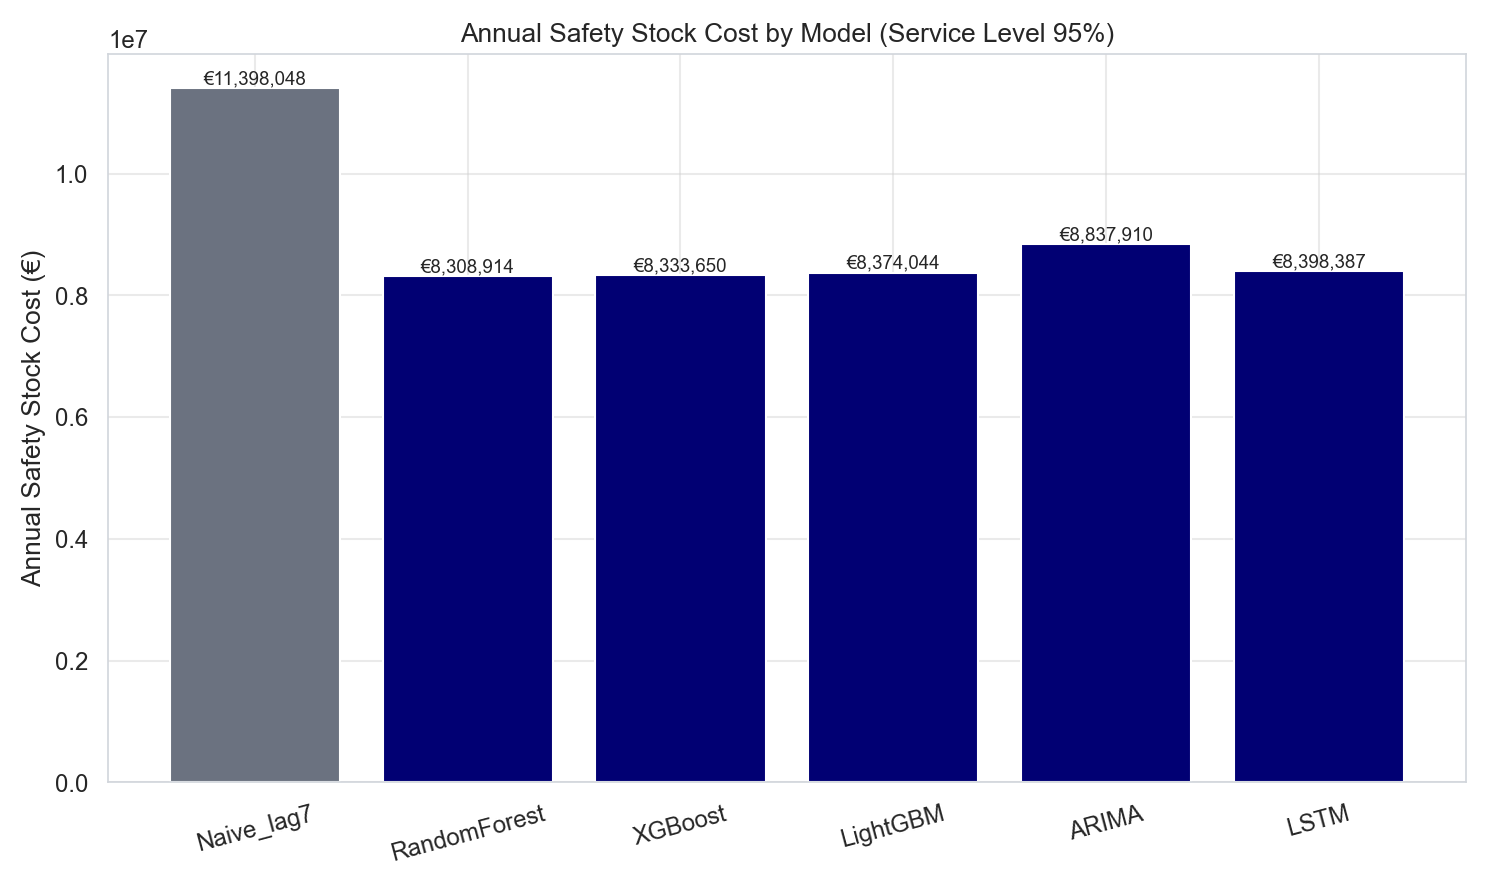

   → Saved 20_annual_cost_comparison.png


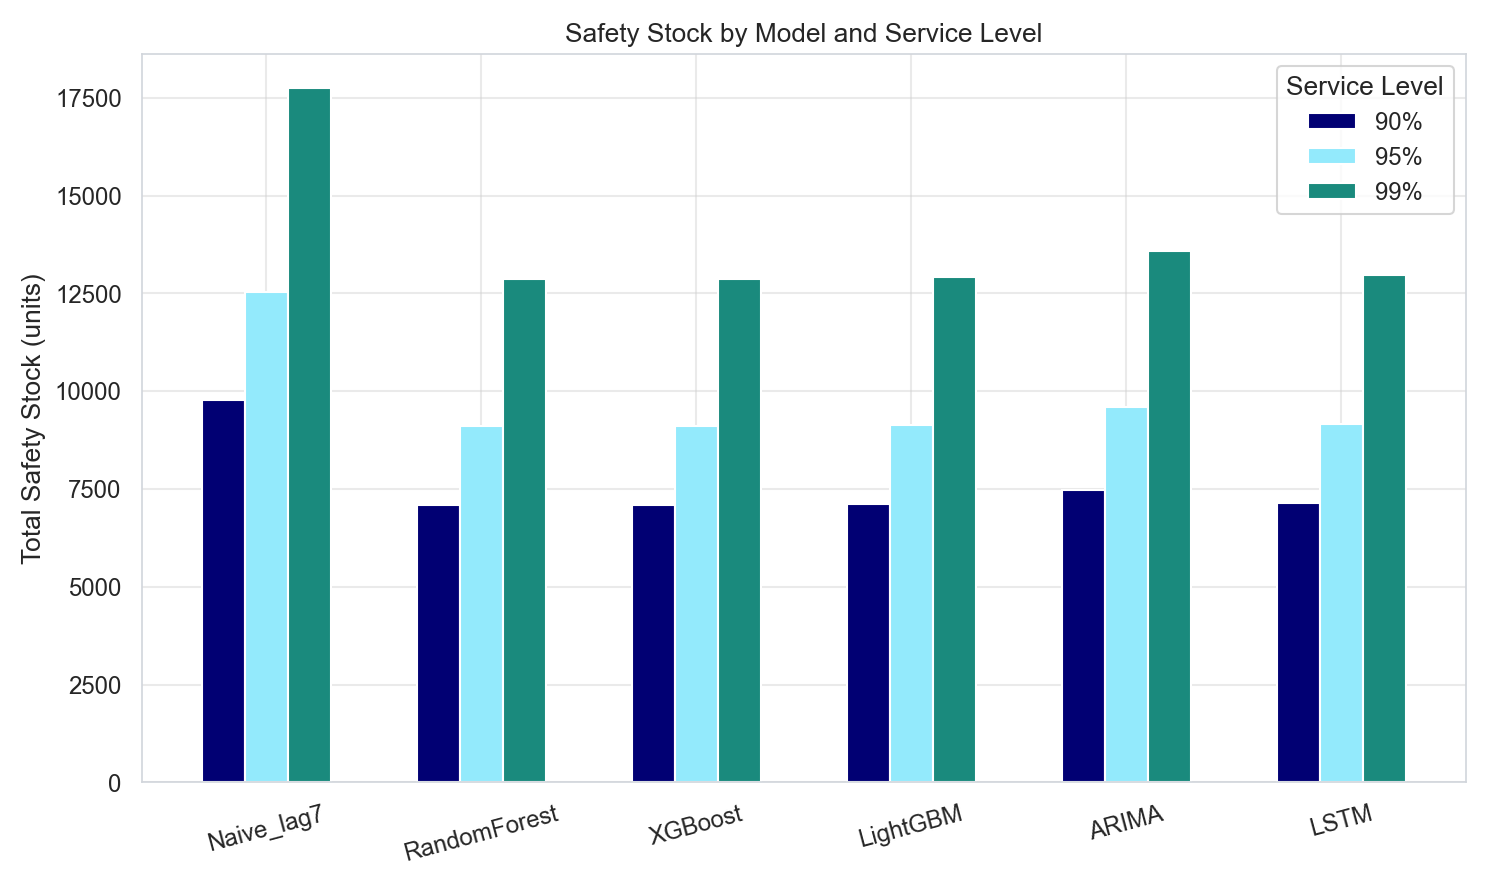

   → Saved 21_safety_stock_by_service_level.png


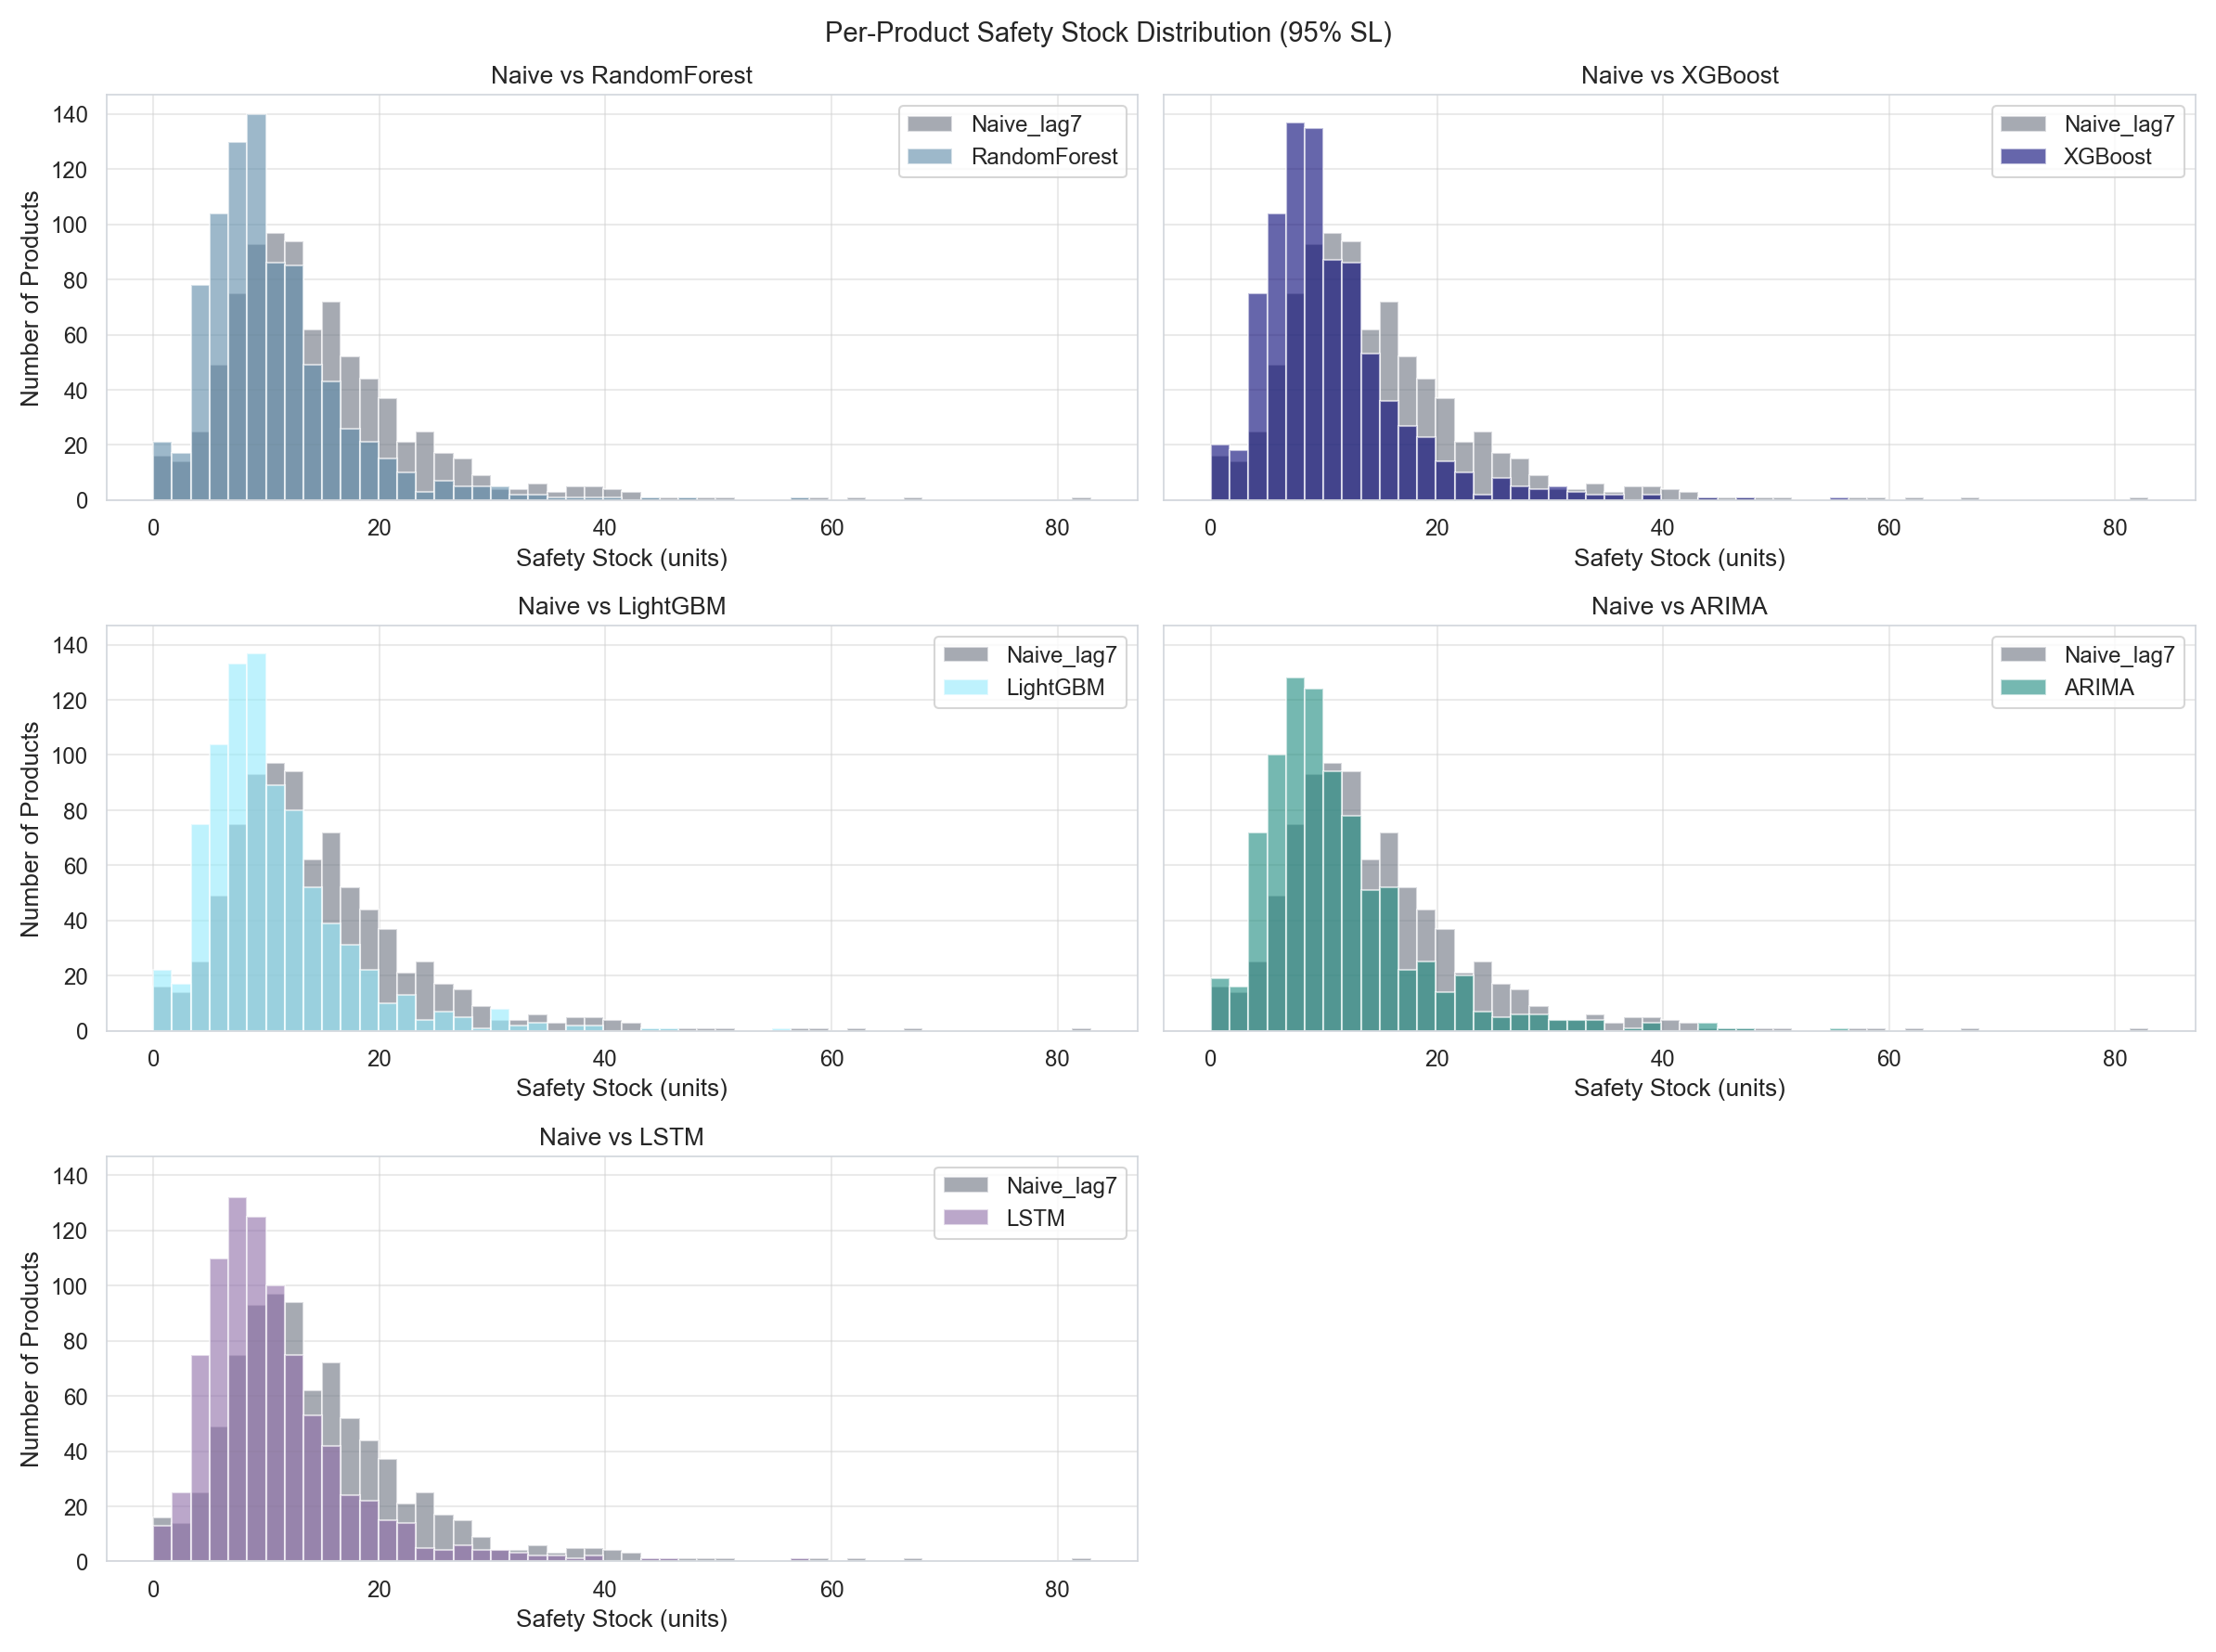

   → Saved 22_safety_stock_distribution.png


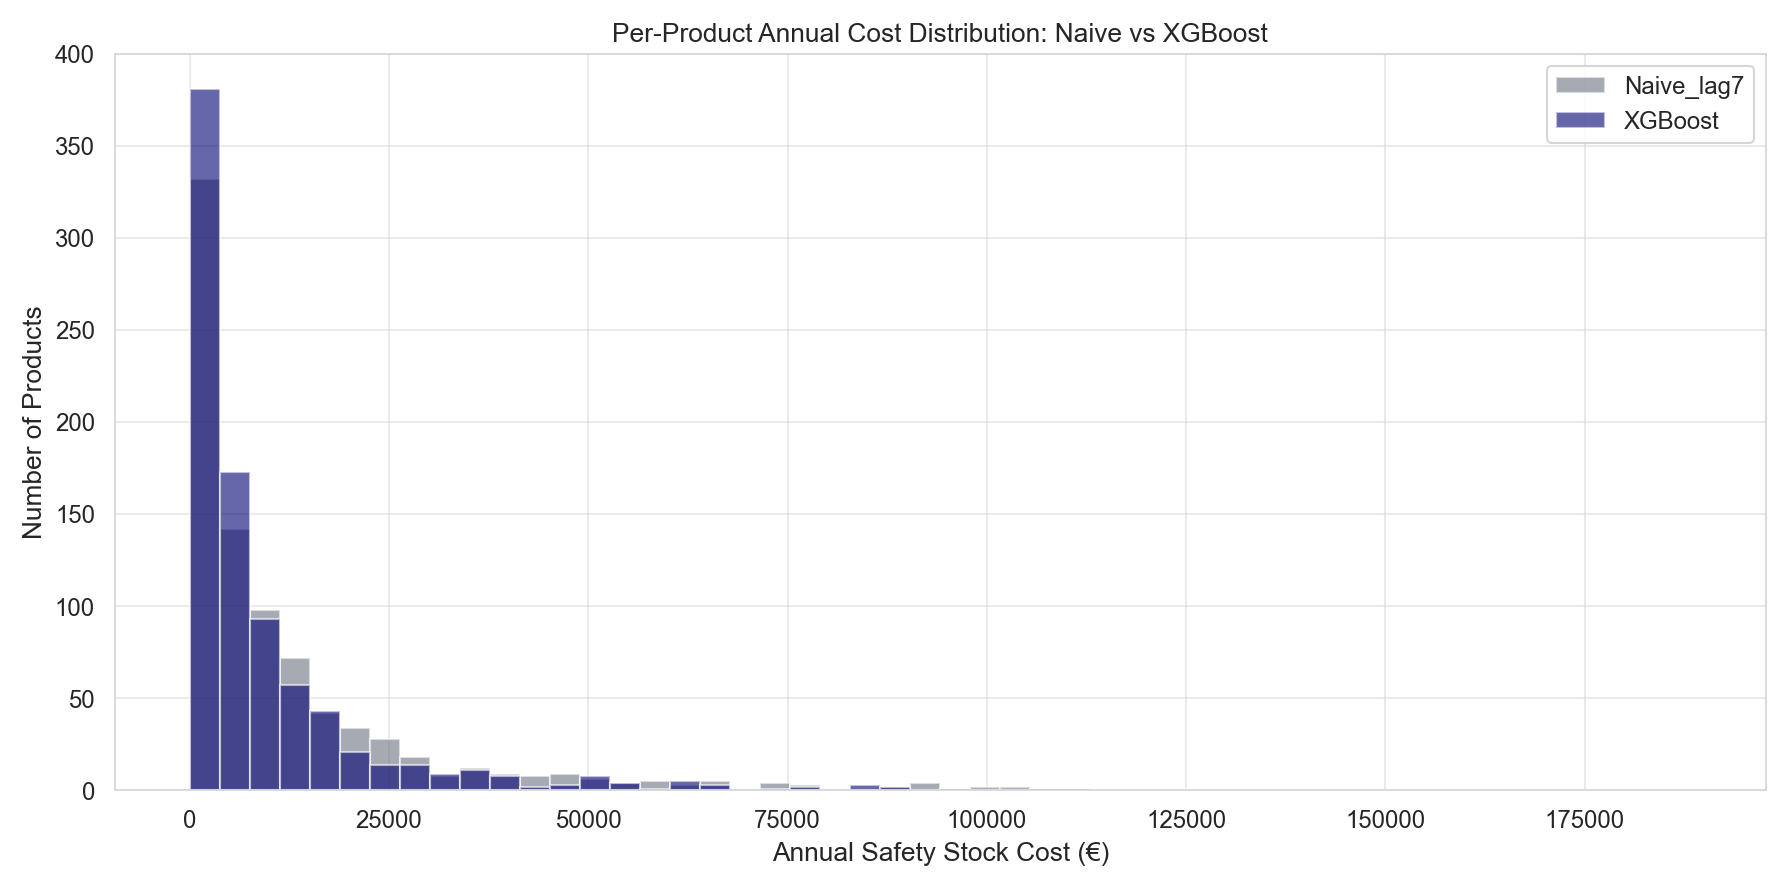

   → Saved 23_annual_cost_distribution.png


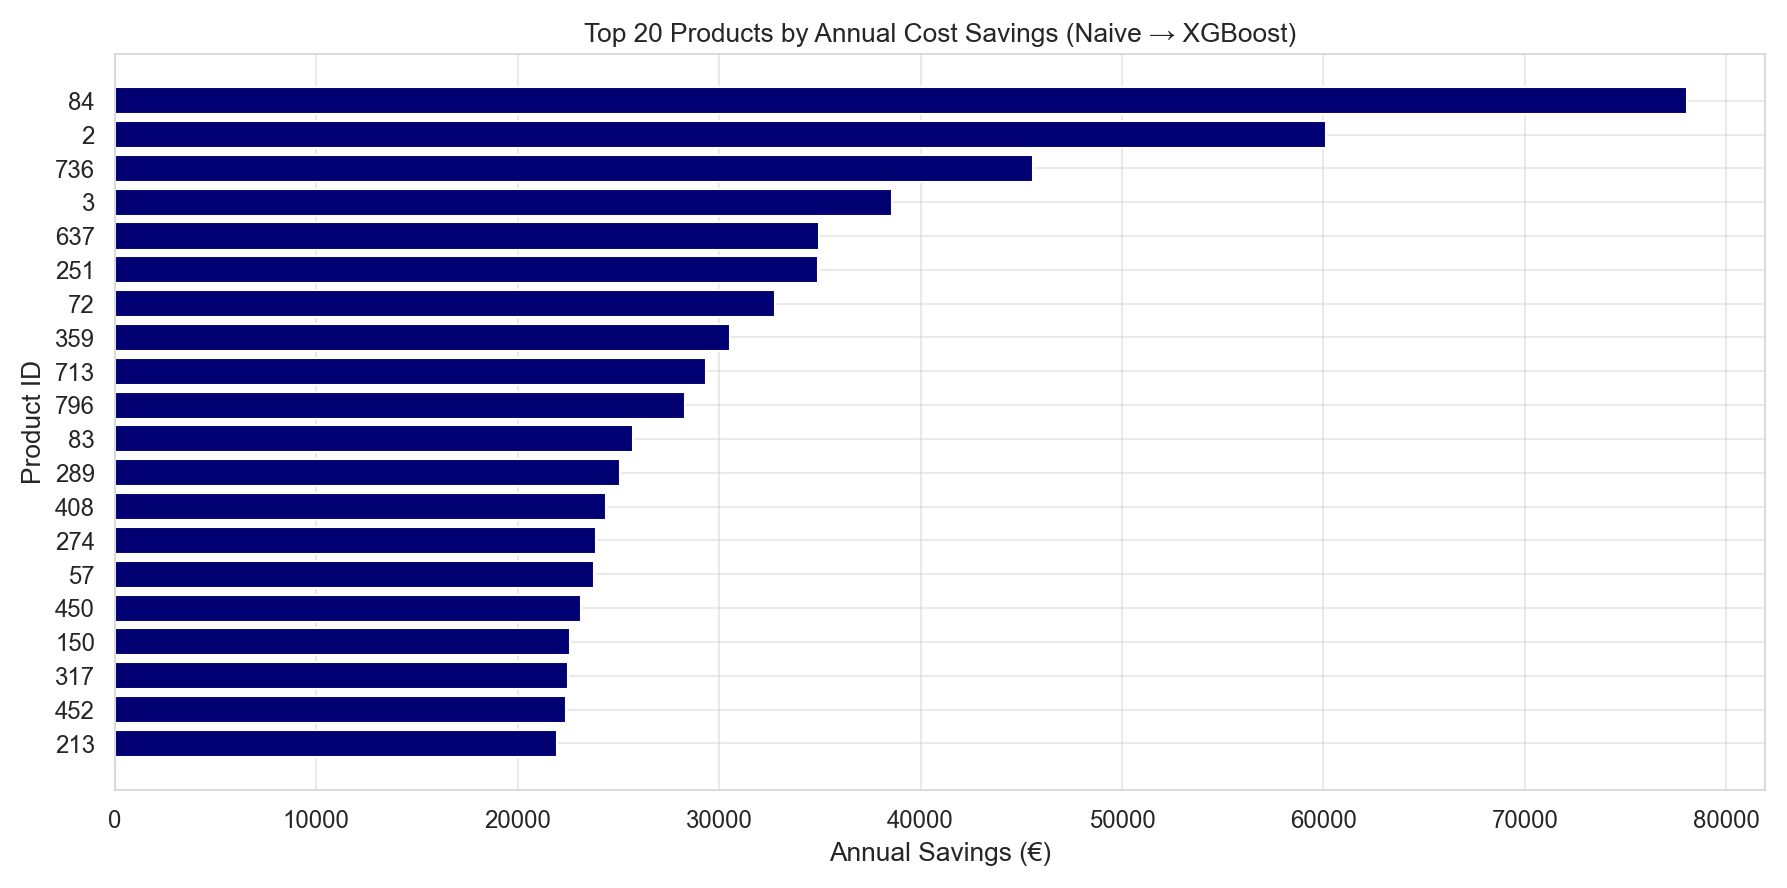

   → Saved 24_top20_savings_by_product.png


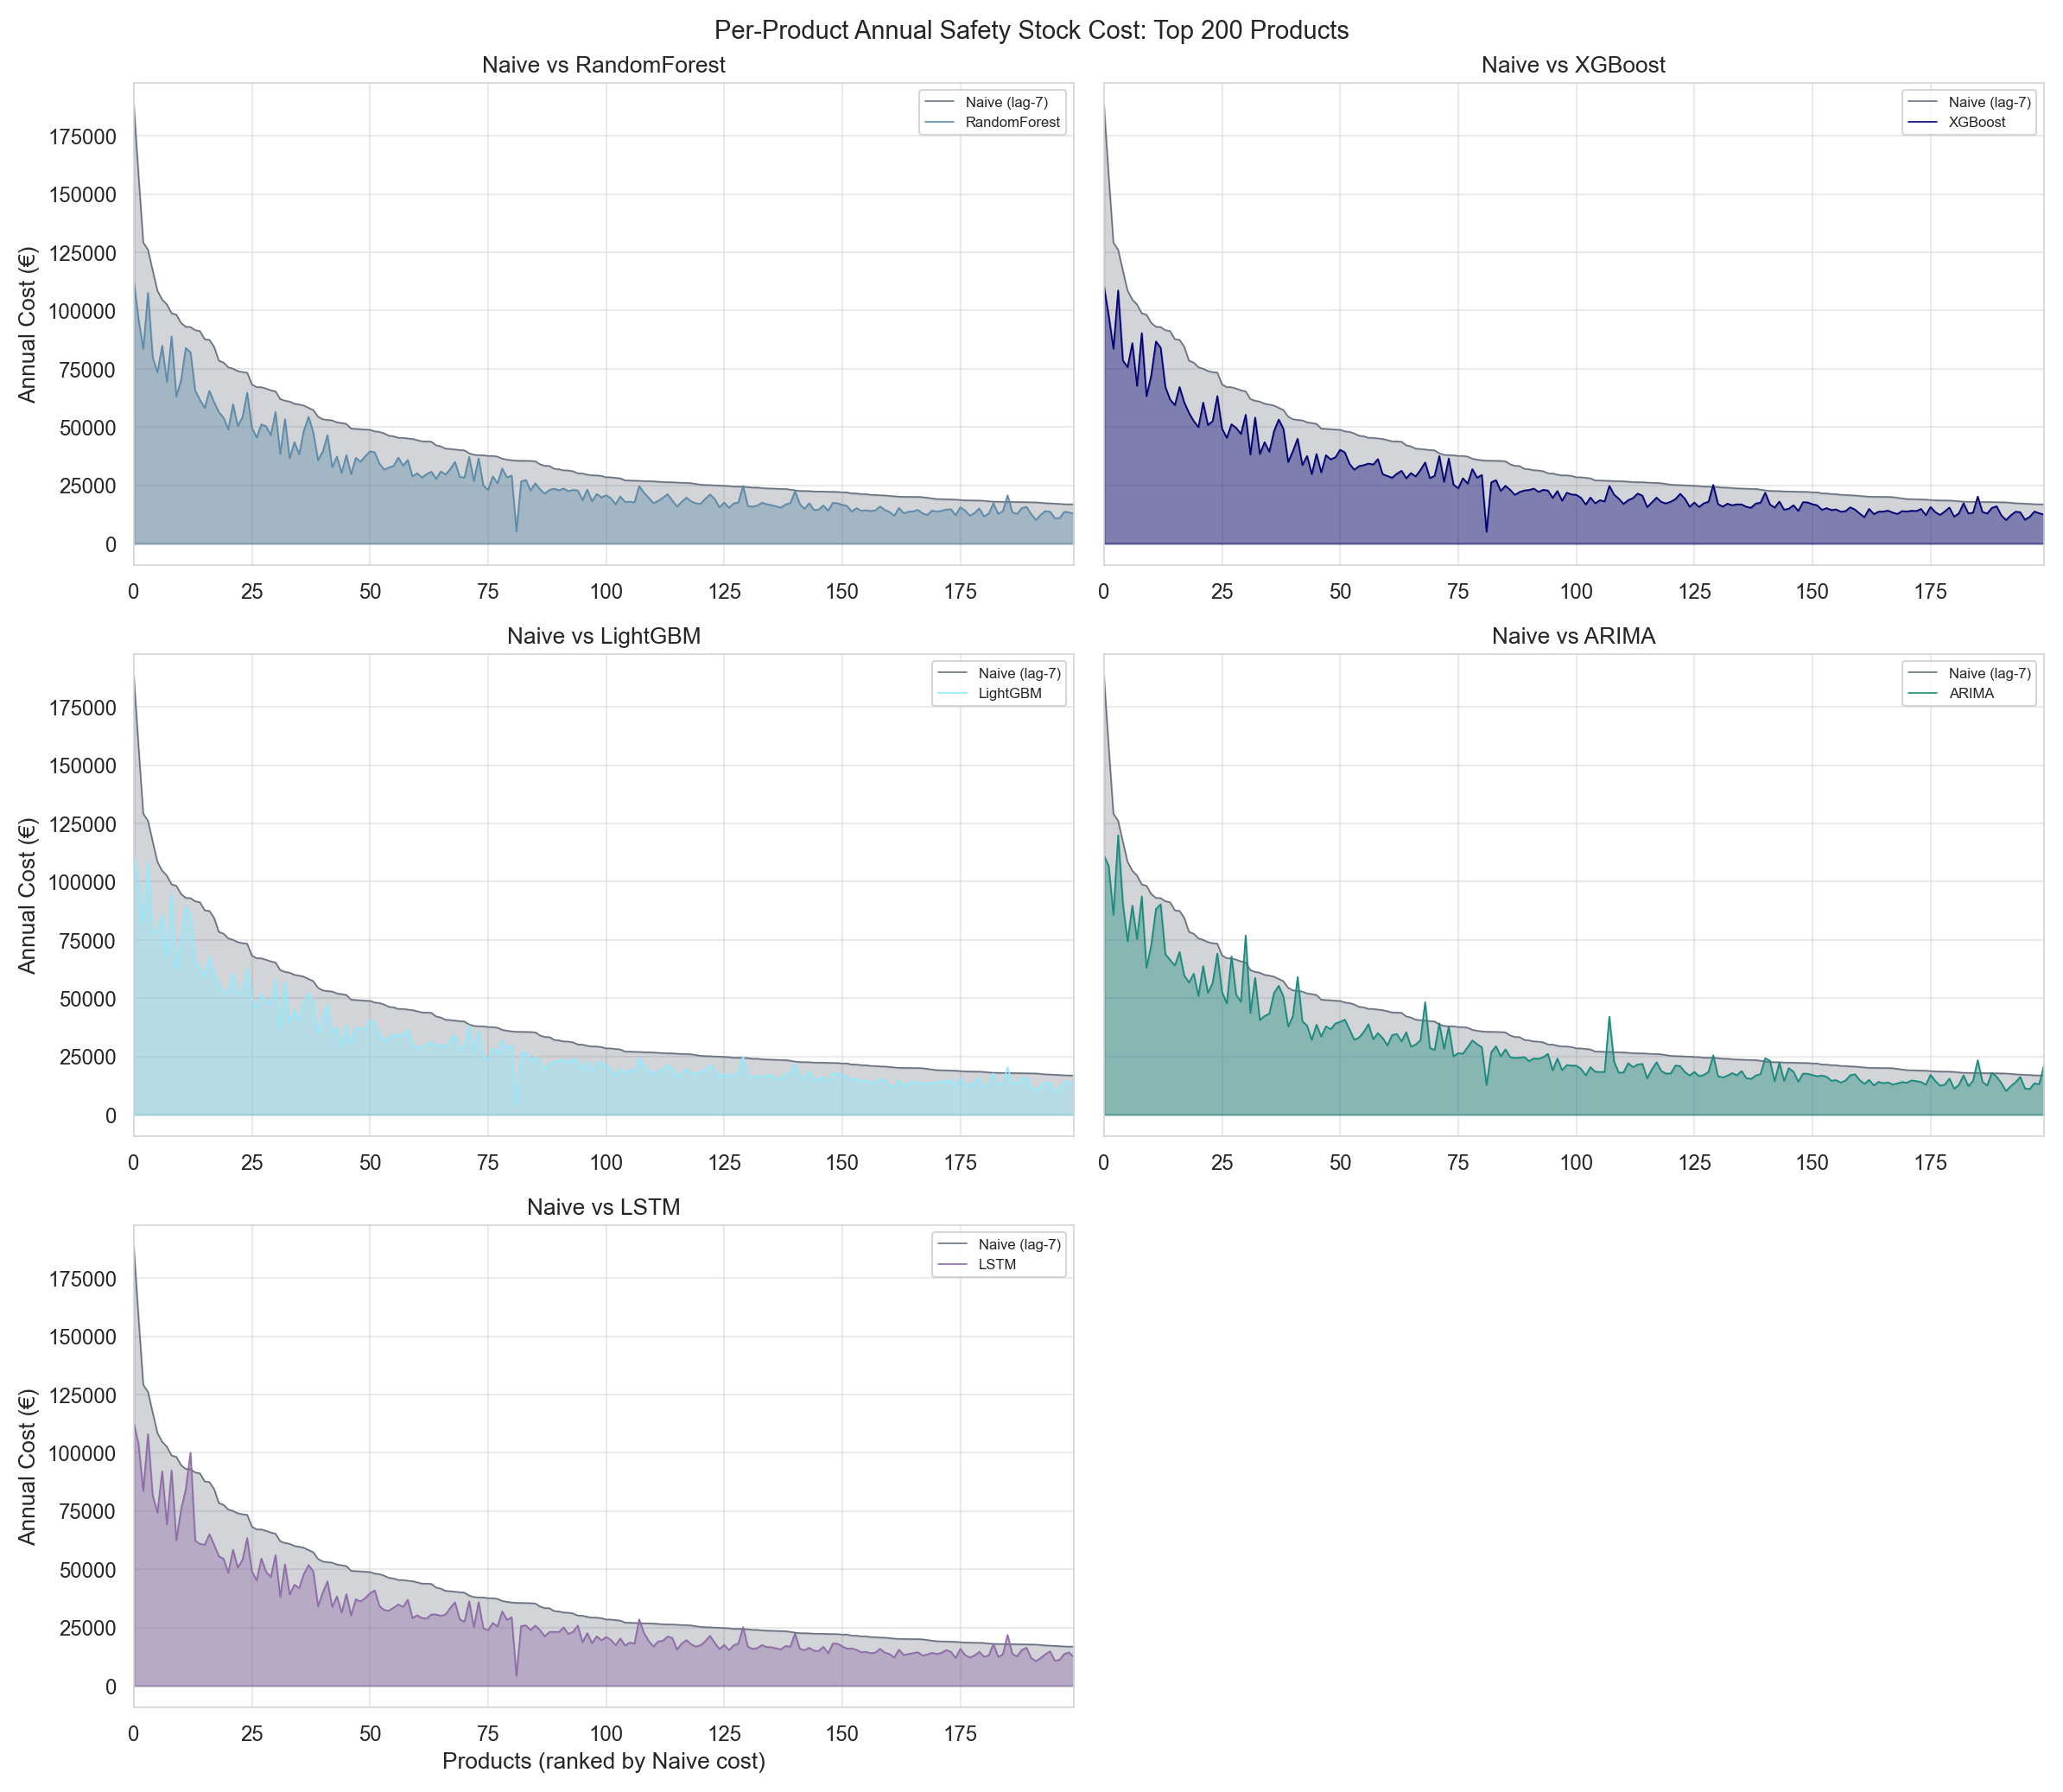

   → Saved 25_per_product_cost_comparison.png

Done.


In [8]:
print('\n' + '=' * 60)
print('7. GENERATING PLOTS')
print('=' * 60)

# 7.1 Annual cost comparison
fig, ax = plt.subplots(figsize=(10, 6))
colors = [SLATE if m == 'Naive_lag7' else DARK_BLUE for m in MODELS]
bars = ax.bar(MODELS, [total_annual[m] for m in MODELS], color=colors, edgecolor='white')
ax.set_ylabel('Annual Safety Stock Cost (\u20ac)')
ax.set_title(f'Annual Safety Stock Cost by Model (Service Level {SERVICE_LEVEL*100:.0f}%)')
for bar, model in zip(bars, MODELS):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'\u20ac{total_annual[model]:,.0f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15)
save_fig('20_annual_cost_comparison')

# 7.2 Safety stock by service level
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
x = np.arange(len(MODELS))
sl_colors = [DARK_BLUE, LIGHT_BLUE, TEAL]
for i, (sl, z_val) in enumerate(SERVICE_LEVELS.items()):
    vals = []
    for m in MODELS:
        v = (z_val * rmse_df[m] * cost_params.set_index('producto')['sqrt_protection']).dropna().sum()
        vals.append(v)
    ax.bar(x + i * bar_width, vals, bar_width, label=f'{sl*100:.0f}%', color=sl_colors[i])
ax.set_xticks(x + bar_width)
ax.set_xticklabels(MODELS, rotation=15)
ax.set_ylabel('Total Safety Stock (units)')
ax.set_title('Safety Stock by Model and Service Level')
ax.legend(title='Service Level')
save_fig('21_safety_stock_by_service_level')

# 7.3 Per-product safety stock distribution
ml_models = ['RandomForest', 'XGBoost', 'LightGBM', 'ARIMA', 'LSTM']
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharey=True)
axes_flat = axes.flatten()
for i, ml_model in enumerate(ml_models):
    ax = axes_flat[i]
    ml_color = get_model_color(ml_model)
    ss_compare = pd.DataFrame({
        'Naive_lag7': ss_df['Naive_lag7'],
        ml_model: ss_df[ml_model],
    })
    ss_compare.plot(kind='hist', bins=50, alpha=0.6, ax=ax, edgecolor='white',
                    color=[get_model_color('Naive_lag7'), ml_color])
    ax.set_title(f'Naive vs {ml_model}')
    ax.set_xlabel('Safety Stock (units)')
    if i % 2 == 0:
        ax.set_ylabel('Number of Products')
axes_flat[-1].set_visible(False)
plt.suptitle('Per-Product Safety Stock Distribution (95% SL)', fontsize=14)
save_fig('22_safety_stock_distribution')

# 7.4 Per-product annual cost distribution
fig, ax = plt.subplots(figsize=(12, 6))
cost_compare = pd.DataFrame({
    'Naive_lag7': cost_annual_df['Naive_lag7'],
    'XGBoost': cost_annual_df['XGBoost'],
})
cost_compare.plot(kind='hist', bins=50, alpha=0.6, ax=ax, edgecolor='white',
                  color=[SLATE, DARK_BLUE])
ax.set_title('Per-Product Annual Cost Distribution: Naive vs XGBoost')
ax.set_xlabel('Annual Safety Stock Cost (\u20ac)')
ax.set_ylabel('Number of Products')
save_fig('23_annual_cost_distribution')

# 7.5 Top 20 products by cost savings
savings_per_product = cost_annual_df['Naive_lag7'] - cost_annual_df['XGBoost']
top20_savings = savings_per_product.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20_savings.index.astype(str), top20_savings.values, color=DARK_BLUE, edgecolor='white')
ax.set_title('Top 20 Products by Annual Cost Savings (Naive \u2192 XGBoost)')
ax.set_xlabel('Annual Savings (\u20ac)')
ax.set_ylabel('Product ID')
ax.invert_yaxis()
save_fig('24_top20_savings_by_product')

# 7.6 Per-product annual cost: Naive vs each ML model (top 200 products)
ml_models = ['RandomForest', 'XGBoost', 'LightGBM', 'ARIMA', 'LSTM']
sorted_idx = cost_annual_df['Naive_lag7'].sort_values(ascending=False).index
top_n = 200
top_idx = sorted_idx[:top_n]
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharey=True)
axes_flat = axes.flatten()
for i, ml_model in enumerate(ml_models):
    ax = axes_flat[i]
    x = np.arange(top_n)
    naive_sorted = cost_annual_df.loc[top_idx, 'Naive_lag7'].values
    ml_sorted = cost_annual_df.loc[top_idx, ml_model].values
    ax.fill_between(x, naive_sorted, alpha=0.3, color=SLATE)
    ax.plot(x, naive_sorted, color=SLATE, linewidth=0.8, label='Naive (lag-7)')
    ml_color = get_model_color(ml_model)
    ax.fill_between(x, ml_sorted, alpha=0.4, color=ml_color)
    ax.plot(x, ml_sorted, color=ml_color, linewidth=0.8, label=ml_model)
    ax.set_title(f'Naive vs {ml_model}')
    ax.legend(loc='upper right', fontsize=8)
    if i >= 4:
        ax.set_xlabel('Products (ranked by Naive cost)')
    if i % 2 == 0:
        ax.set_ylabel('Annual Cost (\u20ac)')
    ax.set_xlim(0, top_n - 1)
axes_flat[-1].set_visible(False)
plt.suptitle(f'Per-Product Annual Safety Stock Cost: Top {top_n} Products', fontsize=14)
save_fig('25_per_product_cost_comparison')

print('\n' + '=' * 60)
print('Done.')
print('=' * 60)


## Documentation

References to the documentation of the main libraries and functions used in this notebook.

1. scipy (2026). *scipy.stats.norm*. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
2. pandas (2026). *pandas.read_parquet*. https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html
